# Sprint3_Part1_ML_EDA (1)

**목표**: EDA 기본적인 과정 경험  
**내용**: 학습 데이터 특징 이해, 모델 성능 향상방안 모색

-----------
# EDA & 데이터 전처리


## 데이터 불러오기 및 정보 확인

In [320]:
# 학습 데이터, 평가 데이터 불러오기
# **test 셋은 타겟 칼럼 ['RentedBikeCount']이 없기 때문에 이후 추가적으로 같이 처리 해준다.
import pandas as pd

url_1 = 'https://raw.githubusercontent.com/rngus4656/datasets/refs/heads/main/S2/SeoulBikeData_train.csv'
url_2 = 'https://raw.githubusercontent.com/rngus4656/datasets/refs/heads/main/S2/SeoulBikeData_test.csv'
df_train = pd.read_csv(url_1)
df_test = pd.read_csv(url_2)

df_train.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,id
0,05/06/2018,742,1,20.0,67,0.7,1426,13.6,0.00,0.0,0.0,Summer,No Holiday,Yes,10019
1,30/10/2018,1442,19,8.0,52,2.1,2000,-1.2,0.00,0.0,0.0,Autumn,No Holiday,Yes,13982
2,05/10/2018,23,12,16.6,90,1.7,518,14.9,0.51,2.0,0.0,Autumn,No Holiday,Yes,12391
3,11/02/2018,93,2,-7.0,42,1.6,2000,-17.7,0.00,0.0,0.0,Winter,No Holiday,Yes,11580
4,28/04/2018,152,5,10.9,81,1.7,348,7.7,0.00,0.0,0.0,Spring,No Holiday,Yes,12042


In [321]:
df_test.head()

,Date,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,id
0,22/11/2018,17,4.9,41,3.3,1985,-7.2,0.25,0.0,0.0,Autumn,No Holiday,Yes,16356
1,05/03/2018,11,6.1,66,1.9,2000,0.2,1.42,0.0,0.0,Spring,No Holiday,Yes,13741
2,30/05/2018,7,18.9,85,0.6,289,16.3,0.12,0.0,0.0,Spring,No Holiday,Yes,10040
3,09/03/2018,19,5.4,60,3.9,990,-1.7,0.02,0.0,0.0,Spring,No Holiday,Yes,15360
4,06/01/2018,19,-1.2,37,1.2,1663,-14.0,0.00,0.0,0.0,Winter,No Holiday,Yes,10802


In [322]:
# test셋은 타겟칼럼이 미포함 된 것 확인(shape)
print(df_train.shape, df_test.shape)
df_train.info()

(7008, 15) (1752, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       7008 non-null   object 
 1   Rented Bike Count          7008 non-null   int64  
 2   Hour                       7008 non-null   int64  
 3   Temperature(°C)            7008 non-null   float64
 4   Humidity(%)                7008 non-null   int64  
 5   Wind speed (m/s)           7008 non-null   float64
 6   Visibility (10m)           7008 non-null   int64  
 7   Dew point temperature(°C)  7008 non-null   float64
 8   Solar Radiation (MJ/m2)    7008 non-null   float64
 9   Rainfall(mm)               7008 non-null   float64
 10  Snowfall (cm)              7008 non-null   float64
 11  Seasons                    7008 non-null   object 
 12  Holiday                    7008 non-null   object 
 13  Functioning Day           

In [323]:
df_train.describe()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),id
count,7008.000000,7008.000000,7008.000000,7008.000000,7008.000000,7008.000000,7008.000000,7008.000000,7008.000000,7008.000000,7008.000000
mean,706.211758,11.512129,13.031107,58.317494,1.728567,1437.730451,4.233790,0.572788,0.142409,0.074886,14375.555936
std,649.132829,6.912871,11.894161,20.366061,1.038034,606.505359,13.014189,0.874385,1.019976,0.437995,2526.380153
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000,10000.000000
25%,190.000000,6.000000,3.700000,43.000000,0.900000,948.000000,-4.400000,0.000000,0.000000,0.000000,12183.750000
50%,509.000000,12.000000,14.000000,57.000000,1.500000,1692.500000,5.200000,0.010000,0.000000,0.000000,14357.500000
75%,1066.000000,17.000000,22.600000,74.000000,2.300000,2000.000000,14.925000,0.930000,0.000000,0.000000,16578.250000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,24.000000,8.800000,18759.000000


In [324]:
df_train.describe(exclude='number')

,Date,Seasons,Holiday,Functioning Day
count,7008,7008,7008,7008
unique,365,4,2,2
top,25/10/2018,Summer,No Holiday,Yes
freq,24,1790,6656,6771


### 결측치 & 중복 확인

In [325]:
print('결측치\n', df_train.isna().sum())
print('중복값\n', df_train.duplicated().sum())

결측치
 Date                         0
Rented Bike Count            0
Hour                         0
Temperature(°C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(°C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
Functioning Day              0
id                           0
dtype: int64
중복값
 0


### 타겟 분포 확인  
> 타겟은 주로 정규분포를 이루도록 하지만, 데이터 특징에따라 방식을 정한다.

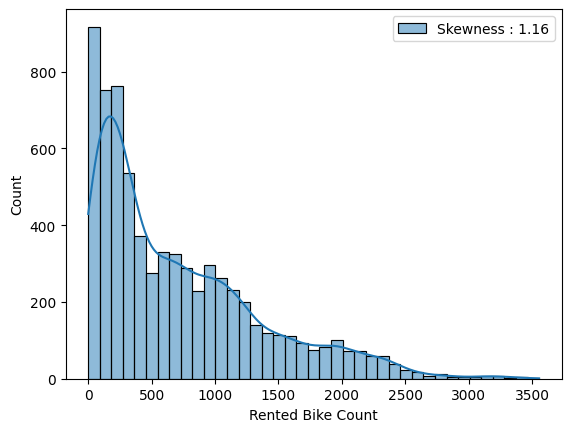

In [326]:
# 타겟칼럼의 정규분포화가 필요할때는 로그변환, Box-Cox, Yeo-Johnson 등의 방법이 있다.
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_train['Rented Bike Count'], kde=True, label=f'Skewness : {df_train['Rented Bike Count'].skew():.2f}')
plt.legend()
plt.show()

# Feature Engineering
> 학습 데이터를 위한 Feature Engineering 단계

In [327]:
# 원본 수정 방지를 위한 copy 생성
df_train2 = df_train.copy()
df_test2 = df_test.copy()

In [328]:
# S2P2 colab(3) 데이터 시각화에서 했던 feature_engineering 적용하는 함수 지정

def feature_engineering(df):
  df_fe = df.copy()
  # Date 월, 요일, 주말여부
  df_fe['Date'] = pd.to_datetime(df_fe['Date'], format='%d/%m/%Y')
  df_fe['month'] = df_fe['Date'].dt.month
  df_fe['dayname'] = df_fe['Date'].dt.day_name()
  df_fe['weekend'] = (df_fe['Date'].dt.weekday >= 5).astype(int)

  # 칼럼 단위 변환
  df_fe['Snowfall (cm)'] = df_fe['Snowfall (cm)'] / 10
  df_fe.rename(columns={'Snowfall (cm)': 'Snowfall (mm)'}, inplace=True)

  # WEP (mm) 칼럼 추가
  df_fe['WEP (mm)'] = df_fe['Rainfall(mm)'] + df_fe['Snowfall (mm)']

  # Date, id, Functioning Day 칼럼 제거 - 데이터 누수 방지, 불필요칼럼 제거
  # df_fe = df_fe.drop(['Date', 'id', 'Functioning Day'], axis=1)
  df_fe = df_fe.drop(['Date', 'id'], axis=1)

  # 1. 불쾌지수 (Discomfort Index)
  # 80 이상: 매우 불쾌, 75~80: 50% 불쾌, 68~75: 불쾌 시작
  df_fe['Discomfort_Index'] = (1.8 * df_fe['Temperature(°C)'] + 32) - \
    (0.55 - 0.0055 * df_fe['Humidity(%)']) * \
    (1.8 * df_fe['Temperature(°C)'] - 26)

  # 2. 고습도 플래그 (비 오기 직전이나 끈적이는 상태)
  # 습도가 80% 이상일 때 1, 아니면 0
  df_fe['Is_Steamy'] = (df_fe['Humidity(%)'] >= 80).astype(int)

  # 3. 쾌적 라이딩 지수 (기온 15~25도 사이 & 습도 30~60% 사이)
  # 가장 자전거 타기 좋은 '골디락스' 날씨 여부
  df_fe['Ideal_Riding'] = ((df_fe['Temperature(°C)'].between(15, 25)) & (df_fe['Humidity(%)'].between(30, 60))).astype(int)

  # 4. 건조 지수 (습도 30% 미만일 때 화재 위험 및 호흡기 불편함 반영)
  df_fe['Is_Dry'] = (df_fe['Humidity(%)'] < 30).astype(int)

  # 이슬점 온도 드랍
  df_fe.drop(columns=['Dew point temperature(°C)'], inplace=True)

  # 비가 오냐?
  df_fe['Is_Raining'] = (df_fe['Rainfall(mm)'] > 0).astype(int)

  # 자외선 컷
  df_fe['Sunlight_Level'] = pd.cut(df_fe['Solar Radiation (MJ/m2)'], bins=[-1, 0.1, 2, 10], labels=[0, 1, 2])


  # 시즌을 드랍
  # df_fe.drop(columns=['Seasons'], inplace=True)

  # 2. 가시성 임계값 (가시거리 10m 단위 기준, 4000m(400) 이하를 저시정으로 판단)
  # 데이터셋의 Visibility 단위를 확인하세요 (보통 2000이 최대값인 경우 400 미만을 추천)
  # df_fe['Low_Visibility'] = (df_fe['Visibility (10m)'] < 400).astype(int)

  # 1. 시간대 다중 플래그 (중첩 허용)
  # df_fe['Time_Night'] = df_fe['Hour'].between(22, 23) | df_fe['Hour'].between(0, 6) # 안 빌리는 시간
  # df_fe['Time_Commute'] = ((df_fe['weekend'] == 0) & df_fe['Hour'].isin([8, 17, 18, 19])).astype(int)
  # df_fe['Time_Weekend_Peak'] = ((df_fe['weekend'] == 1) & df_fe['Hour'].isin([15, 16, 17, 18, 19])).astype(int)

  # 3. 10의 자리 vs 1의 자리 패턴 (사용자 가설 반영)
  # 10~21시 사이의 활성 시간대 강조
  # df_fe['Time_Active_Range'] = df_fe['Hour'].between(7, 21).astype(int)

  # Hour 컬럼을 삭제한 결과를 다시 저장 (inplace=True를 쓰거나 재할당)
  # df_fe.drop(columns=['Hour'], inplace=True)



  # 출퇴근 시간 (7-9시, 18-20시)
  # df_fe['Is_RushHour'] = df_fe['Hour'].isin([7, 8, 9, 18, 19, 20]).astype(int)

  # 3. 새벽 시간 (대여량이 거의 없는 구간을 명시적으로 학습)
  # df_fe['Is_QuietTime'] = df_fe['Hour'].between(1, 5).astype(int)



  # 시간대 카테고리 생성
  # bins = [-1, 5, 11, 17, 23]
  # labels = ['Dawn(0~5)', 'Morning(6~11)', 'Afternoon(12~17)', 'Evening(18~23)']
  # df_fe['Hour_cat'] = pd.cut(df_fe['Hour'], bins=bins, labels=labels)

  # 0~6: 새벽(0), 7~10: 오전(1), 11~16: 낮(2), 17~21: 저녁(3), 22~23: 밤(0)
  # df_fe['Hour_Group'] = pd.cut(df_fe['Hour'],
    # bins=[-1, 6, 10, 16, 21, 24],
    # labels=[0, 1, 2, 3, 0], ordered=False)

  # 1. 출퇴근 시간대 (평일 7~9시, 17~20시)
  #df_fe['Is_Commute'] = ((df_fe['weekend'] == 0) &
                      #((df_fe['Hour'].between(7, 9)) | (df_fe['Hour'].between(17, 20)))).astype(int)

  # 2. 주말 피크 시간대 (주말 10~18시)
  #df_fe['Is_Weekend_Peak'] = ((df_fe['weekend'] == 1) &
                           #(df_fe['Hour'].between(10, 18))).astype(int)

  # 3. 온도와 습도의 불쾌지수 (자전거 타기 좋은 날씨인지)
  # 기온과 습도가 높을 때 대여량이 급감하는 현상 반영
  #df_fe['Discomfort_Index'] = 0.81 * df_fe['Temperature(°C)'] + \
                           #0.01 * df_fe['Humidity(%)'] * (0.99 * df_fe['Temperature(°C)'] - 14.3) + 46.3
  return df_fe


In [329]:
# df_train, df_test에 feature_engineering 함수 적용
fe_train = feature_engineering(df_train2)
fe_test = feature_engineering(df_test2)
fe_train.head()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (mm),Seasons,...,month,dayname,weekend,WEP (mm),Discomfort_Index,Is_Steamy,Ideal_Riding,Is_Dry,Is_Raining,Sunlight_Level
0,742,1,20.0,67,0.7,1426,0.00,0.0,0.0,Summer,...,6,Tuesday,0,0.0,66.18500,0,0,0,0,0
1,1442,19,8.0,52,2.1,2000,0.00,0.0,0.0,Autumn,...,10,Tuesday,0,0.0,49.46240,0,0,0,0,0
2,23,12,16.6,90,1.7,518,0.51,2.0,0.0,Autumn,...,10,Friday,0,2.0,61.66660,1,0,0,1,1
3,93,2,-7.0,42,1.6,2000,0.00,0.0,0.0,Winter,...,2,Sunday,1,0.0,31.71340,0,0,0,0,0
4,152,5,10.9,81,1.7,348,0.00,0.0,0.0,Spring,...,4,Saturday,1,0.0,52.28671,1,0,0,0,0


# 학습 데이터셋 분리  
> 모델이 학습할 데이터 train  
학습모델을 검증할 데이터 val  
최종 성능을 평가할 데이터 test

In [330]:
# train(문제집 학습), val(모의고사), test(수능)

from sklearn.model_selection import train_test_split

X = fe_train.drop('Rented Bike Count', axis=1) # 독립변수 X (학습 칼럼)
y = fe_train['Rented Bike Count'] # 종속변수 y (타겟 칼럼 분리)
X_test = fe_test.copy() # (예측해야 할 테스트 데이터 셋)

# 학습 데이터셋, 검증 데이터셋 분리
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42)
X_train.shape, X_val.shape, X_test.shape

((5256, 21), (1752, 21), (1752, 21))

In [331]:
X_train.head()

,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (mm),Seasons,Holiday,...,month,dayname,weekend,WEP (mm),Discomfort_Index,Is_Steamy,Ideal_Riding,Is_Dry,Is_Raining,Sunlight_Level
4369,7,17.8,76,0.5,1729,0.08,0.0,0.0,Autumn,No Holiday,...,9,Tuesday,0,0.0,63.24272,0,0,0,0,0
5995,3,-8.6,68,3.3,2000,0.00,0.0,0.1,Winter,No Holiday,...,1,Tuesday,0,0.1,23.82048,0,0,0,0,0
3181,3,-6.5,42,0.7,1996,0.00,0.0,0.0,Winter,No Holiday,...,1,Saturday,1,0.0,32.32630,0,0,0,0,0
2676,9,29.7,58,1.3,1955,1.68,0.0,0.0,Summer,No Holiday,...,8,Saturday,1,0.0,79.11674,0,0,0,0,1
2417,12,7.9,14,1.7,1688,1.81,0.0,0.0,Autumn,No Holiday,...,11,Wednesday,0,0.0,51.79194,0,0,1,0,1


# 데이터 전처리  

> 데이터 전처리(Data Preprocessing)  
모델이 학습할 수 있도록 원본 데이터를 적절한 형태로 변환하는 과정이다.  
범주형 변수 인코딩, 스케일링 등의 작업을 포함한다.  
모델의 성능과 안정성에 직접적인 영향을 미치는 중요한 단계

In [332]:
cat_cols = X.select_dtypes(exclude='number').columns
numeric = X.select_dtypes(include='number').columns
print('범주형 칼럼:', cat_cols)
print('수치형 칼럼:', numeric)

범주형 칼럼: Index(['Seasons', 'Holiday', 'Functioning Day', 'dayname', 'Sunlight_Level'], dtype='object')
수치형 칼럼: Index(['Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)',
       'Visibility (10m)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)',
       'Snowfall (mm)', 'month', 'weekend', 'WEP (mm)', 'Discomfort_Index',
       'Is_Steamy', 'Ideal_Riding', 'Is_Dry', 'Is_Raining'],
      dtype='object')


## 범주형 인코딩

In [333]:
# One Hot Encoding - 가장 대표적인 범주형 인코딩 방식, 라벨 인코딩, 타겟 인코딩 등의 다양한 방식이 있다.

from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

X_train_ohe = ohe.fit_transform(X_train[cat_cols])
X_val_ohe = ohe.transform(X_val[cat_cols])
X_test_ohe = ohe.transform(X_test[cat_cols])

In [334]:
# 인코딩된 값을 적용하기위해 데이터프레임 형식으로 변환
ohe_cat_cols = ohe.get_feature_names_out(cat_cols)

X_train_ohe = pd.DataFrame(X_train_ohe, columns=ohe_cat_cols)
X_val_ohe = pd.DataFrame(X_val_ohe, columns=ohe_cat_cols)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=ohe_cat_cols)
X_train_ohe # X_train 정보와 비교해보면 쉽게 이해할 수 있다.

,Seasons_Autumn,Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_Holiday,Holiday_No Holiday,Functioning Day_No,Functioning Day_Yes,dayname_Friday,dayname_Monday,dayname_Saturday,dayname_Sunday,dayname_Thursday,dayname_Tuesday,dayname_Wednesday,Sunlight_Level_0,Sunlight_Level_1,Sunlight_Level_2
0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5251,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5252,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
5253,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5254,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


## 수치형 스케일링

In [335]:
# 수치형 칼럼의 스케일링

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[numeric])
X_val_scaled = scaler.transform(X_val[numeric])
X_test_scaled = scaler.transform(X_test[numeric])

X_train_scaled = pd.DataFrame(X_train_scaled, columns=numeric)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=numeric)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=numeric)
X_train_scaled.head()

,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (mm),month,weekend,WEP (mm),Discomfort_Index,Is_Steamy,Ideal_Riding,Is_Dry,Is_Raining
0,-0.645758,0.397822,0.859610,-1.192648,0.479398,-0.555978,-0.141253,-0.178106,0.711006,-0.632835,-0.147456,0.424277,-0.478133,-0.373017,-0.274784,-0.261744
1,-1.219450,-1.821026,0.468220,1.526183,0.925874,-0.647578,-0.141253,2.385915,-1.626841,-0.632835,-0.056116,-2.051273,-0.478133,-0.373017,-0.274784,-0.261744
2,-1.219450,-1.644527,-0.803798,-0.998445,0.919284,-0.647578,-0.141253,-0.178106,-1.626841,1.580192,-0.147456,-1.517143,-0.478133,-0.373017,-0.274784,-0.261744
3,-0.358912,1.397985,-0.021018,-0.415839,0.851736,1.276007,-0.141253,-0.178106,0.418775,1.580192,-0.147456,1.421099,-0.478133,-0.373017,-0.274784,-0.261744
4,0.071357,-0.434246,-2.173663,-0.027434,0.411850,1.424855,-0.141253,-0.178106,1.295468,-0.632835,-0.147456,-0.294783,-0.478133,-0.373017,3.639217,-0.261744


## 인코딩 + 스케일링 데이터 합치기

In [336]:
# 범주형, 수치형 전처리 데이터 concat

X_tr_EDA = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_va_EDA = pd.concat([X_val_ohe, X_val_scaled], axis=1)
X_te_EDA = pd.concat([X_test_ohe, X_test_scaled], axis=1)
X_tr_EDA.head() #훈련용 데이터셋 전처리 완료

,Seasons_Autumn,Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_Holiday,Holiday_No Holiday,Functioning Day_No,Functioning Day_Yes,dayname_Friday,dayname_Monday,...,Rainfall(mm),Snowfall (mm),month,weekend,WEP (mm),Discomfort_Index,Is_Steamy,Ideal_Riding,Is_Dry,Is_Raining
0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,-0.141253,-0.178106,0.711006,-0.632835,-0.147456,0.424277,-0.478133,-0.373017,-0.274784,-0.261744
1,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,-0.141253,2.385915,-1.626841,-0.632835,-0.056116,-2.051273,-0.478133,-0.373017,-0.274784,-0.261744
2,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,-0.141253,-0.178106,-1.626841,1.580192,-0.147456,-1.517143,-0.478133,-0.373017,-0.274784,-0.261744
3,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,-0.141253,-0.178106,0.418775,1.580192,-0.147456,1.421099,-0.478133,-0.373017,-0.274784,-0.261744
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,-0.141253,-0.178106,1.295468,-0.632835,-0.147456,-0.294783,-0.478133,-0.373017,3.639217,-0.261744


# 데이터 전처리 자동화

> def 지정함수를 사용하면 쉽게 전처리를 자동화 할 수 있다.

In [337]:
# 데이터셋 전처리 함수

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

def preprocessing(train_df, test_df, test_size=0.25, random_state=42, drop_cols=True):
  # 1) df복사 및 불필요 칼럼 삭제
  train2 = train_df.copy()
  test2  = test_df.copy()
  if drop_cols:
    # train2 = train2.drop(['Date', 'id', 'Functioning Day'], axis=1)
    # test2  = test2.drop(['Date', 'id', 'Functioning Day'], axis=1)
    train2 = train2.drop(['Date', 'id'], axis=1)
    test2  = test2.drop(['Date', 'id'], axis=1)


  # train_test_split
  X = train2.drop('Rented Bike Count', axis=1) # 독립변수 X (학습 칼럼)
  y = train2['Rented Bike Count'] # 종속변수 y (타겟 칼럼 분리)
  X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=test_size, random_state=random_state)

  # 범주형 칼럼 OneHotEncoding
  cat_cols = X_tr.select_dtypes(exclude="number").columns
  ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
  X_tr_ohe = ohe.fit_transform(X_tr[cat_cols])
  X_va_ohe = ohe.transform(X_va[cat_cols])
  X_te_ohe = ohe.transform(test2[cat_cols])
  ohe_cat_cols = ohe.get_feature_names_out(cat_cols)

  X_tr_ohe = pd.DataFrame(X_tr_ohe, columns=ohe_cat_cols)
  X_va_ohe = pd.DataFrame(X_va_ohe, columns=ohe_cat_cols)
  X_te_ohe = pd.DataFrame(X_te_ohe, columns=ohe_cat_cols)

  # 수치형 칼럼의 스케일링
  numeric = X_tr.select_dtypes(include="number").columns

  scaler = StandardScaler()
  X_tr_scaled = scaler.fit_transform(X_tr[numeric])
  X_va_scaled = scaler.transform(X_va[numeric])
  X_te_scaled = scaler.transform(test2[numeric])

  X_tr_scaled = pd.DataFrame(X_tr_scaled, columns=numeric)
  X_va_scaled = pd.DataFrame(X_va_scaled, columns=numeric)
  X_te_scaled = pd.DataFrame(X_te_scaled, columns=numeric)

  # 범주형, 수치형 전처리 데이터 concat
  X_tr_2 = pd.concat([X_tr_ohe, X_tr_scaled], axis=1)
  X_va_2 = pd.concat([X_va_ohe, X_va_scaled], axis=1)
  X_te_2 = pd.concat([X_te_ohe, X_te_scaled], axis=1)

  print('훈련용 데이터셋 전처리 완료')

  return X_tr_2, X_va_2, X_te_2

In [338]:
# EDA 미적용 baseline dataset 생성
X_tr_ba, X_va_ba, X_te_ba = preprocessing(df_train, df_test)

# EDA 적용 dataset 생성예시 (이미 위에서 만들었지만 다시 만들어야할 경우)
fe_train = feature_engineering(df_train)
fe_test = feature_engineering(df_test)
X_tr_EDA, X_va_EDA, X_te_EDA = preprocessing(fe_train, fe_test, drop_cols=False)

훈련용 데이터셋 전처리 완료
훈련용 데이터셋 전처리 완료


# 모델 학습 및 테스트

In [339]:
# DT, RF, XGB 회귀모델 성능평가

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 의사결정나무, 랜덤 포레스트, XGB부스트 모델
dt = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
# xgb = XGBRegressor(n_estimators=100, n_jobs=-1, random_state=42)
xgb = XGBRegressor(colsample_bytree=0.7,learning_rate=0.05, n_estimators=1000, n_jobs=-1, random_state=42)


In [340]:
# EDA 데이터셋 학습 및 성능평가 비교

X_tr = [X_tr_ba, X_tr_EDA]
X_va = [X_va_ba, X_va_EDA]
names = ['basic', 'EDA']

for i in range(len(names)):
  print(f"{names[i]}")
  # Decision Tree
  dt.fit(X_tr[i], y_train)
  dt_pred = dt.predict(X_va[i])

  # Random Forest
  rf.fit(X_tr[i], y_train)
  rf_pred = rf.predict(X_va[i])

  # XGBoost
  xgb.fit(X_tr[i], y_train)
  xgb_pred = xgb.predict(X_va[i])

  def evaluate(y_true, y_pred, model_name):
      rmse = np.sqrt(mean_squared_error(y_true, y_pred))
      r2 = r2_score(y_true, y_pred)
      print(f"{model_name}")
      print(f"RMSE: {rmse:.3f}")
      print(f"R2: {r2:.3f}")
      print("-"*30)

  evaluate(y_val, dt_pred, "Decision Tree")
  evaluate(y_val, rf_pred, "Random Forest")
  evaluate(y_val, xgb_pred, "XGBoost")

basic
Decision Tree
RMSE: 324.027
R2: 0.743
------------------------------
Random Forest
RMSE: 240.347
R2: 0.859
------------------------------
XGBoost
RMSE: 227.370
R2: 0.873
------------------------------
EDA
Decision Tree
RMSE: 247.137
R2: 0.850
------------------------------
Random Forest
RMSE: 174.067
R2: 0.926
------------------------------
XGBoost
RMSE: 151.895
R2: 0.943
------------------------------


## Feature Importance 확인하기  

> Feature Importance
- 트리 기반 모델에서 불순도 감소량을 기준으로 계산되는 변수 중요도
- 여러 트리의 중요도를 평균하여 산출
- 연속형 변수나 범주 수가 많은 변수에 편향될 수 있음

In [341]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_feature_importance_subplot(models, X, model_names):

    fig, axes = plt.subplots(1, len(models), figsize=(6*len(models), 6))

    if len(models) == 1:
        axes = [axes]

    for ax, model, name in zip(axes, models, model_names):

        fi = pd.Series(model.feature_importances_,
                       index=X.columns).sort_values(ascending=False).head(20)

        fi.plot(kind="barh", ax=ax)

        ax.set_title(f"{name} Feature Importance")
        ax.set_xlabel("Importance")

        ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

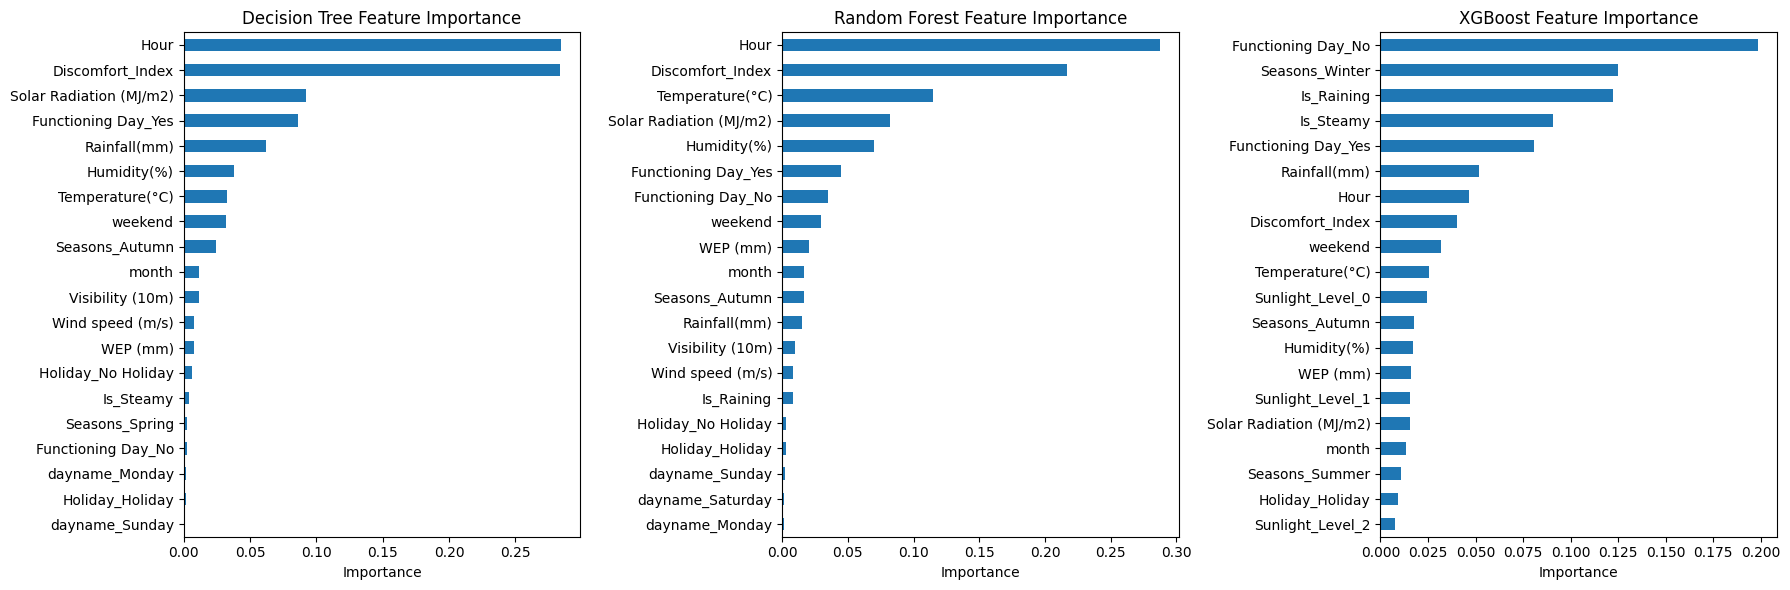

In [342]:
models = [dt, rf, xgb]
names = ["Decision Tree", "Random Forest", "XGBoost"]

plot_feature_importance_subplot(models, X_tr_EDA, names)

## Permutation Importance 확인하기

> Permutation Importance
- 특정 변수를 무작위로 섞었을 때 모델 성능 감소량으로 중요도 측정
- 모델 재학습 없이 계산 가능, Feature Importance보다 신뢰도가 높은편
- 변수 간 상관관계가 높으면 왜곡될 수 있음

In [343]:
from sklearn.inspection import permutation_importance

def plot_permutation_importance_subplot(models, X_val, y_val, model_names):

    fig, axes = plt.subplots(1, len(models), figsize=(6*len(models), 6))

    if len(models) == 1:
        axes = [axes]

    for ax, model, name in zip(axes, models, model_names):

        result = permutation_importance(
            model,
            X_val,
            y_val,
            n_repeats=10,
            random_state=42,
            n_jobs=-1
        )

        perm_importance = pd.Series(
            result.importances_mean,
            index=X_val.columns
        ).sort_values(ascending=False).head(20)

        perm_importance.plot(kind="barh", ax=ax)

        ax.set_title(f"{name} Permutation Importance")
        ax.set_xlabel("Mean Decrease in Score")

        ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

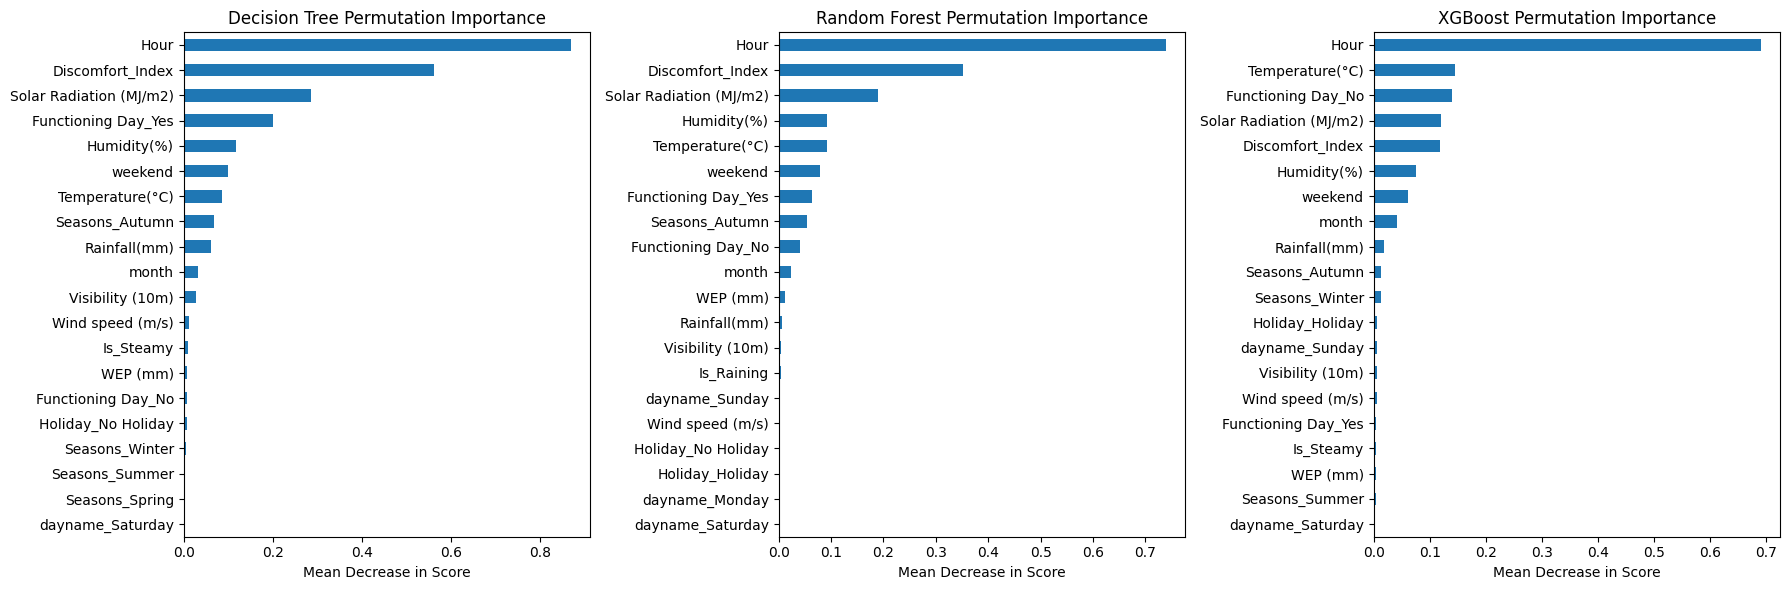

In [344]:
models = [dt, rf, xgb]
names = ["Decision Tree", "Random Forest", "XGBoost"]

plot_permutation_importance_subplot(models, X_va_EDA, y_val, names)

# 오래 걸림 얘는
# print("--- [진단] Train Data 기준 Permutation Importance ---")
# plot_permutation_importance_subplot(models, X_tr_EDA, y_train, names)

# 실습 목표
DAY 1) EDA 데이터셋에서 최소 한가지 이상의 피쳐 엔지니어링을 해보세요.

In [345]:
# X_tr_EDA["Weather_index"] = X_tr_EDA["Temperature(°C)"] * (1 - X_tr_EDA["Humidity(%)"]/100)
# X_va_EDA["Weather_index"] = X_va_EDA["Temperature(°C)"] * (1 - X_va_EDA["Humidity(%)"]/100)
# X_te_EDA["Weather_index"] = X_te_EDA["Temperature(°C)"] * (1 - X_te_EDA["Humidity(%)"]/100)

In [346]:
# X_tr_EDA["Temp_hour"] = X_tr_EDA["Temperature(°C)"] * X_tr_EDA["Hour"]
# X_va_EDA["Temp_hour"] = X_va_EDA["Temperature(°C)"] * X_va_EDA["Hour"]
# X_te_EDA["Temp_hour"] = X_te_EDA["Temperature(°C)"] * X_te_EDA["Hour"]

-----
# Sprint3_Part1_ML_EDA (2)

**목표**: ML 하이퍼파라미터 튜닝 및 성능 테스트  
**내용**: 머신러닝 하이퍼파라미터 조정, 성능평가, PCA/클러스터링 이해

# 모델 하이퍼 파라미터 튜닝 및 테스트  
따로 스크롤 올려가면서 확인하기 불편하신 분들은  
[하이퍼 파라미터 설명 페이지](https://github.com/rngus4656/wassup13/blob/main/Sprint3/DT_RF_XGB_%ED%95%98%EC%9D%B4%ED%8D%BC%ED%8C%8C%EB%9D%BC%EB%AF%B8%ED%84%B0.md)를 따로 띄워놓으셔도 됩니다.

## 의사결정나무 회귀모델(Decision TreeRegressor) 하이퍼 파라미터  
> 의사결정나무  
데이터를 분할 기준에 따라 반복적으로 나누어 예측값을 도출하는 기본적인 트리모델이다.  
각 분기 과정이 명확하게 드러나기 때문에 예측 근거를 설명하기 용이하다.

- 단순 트리구조로 성능이 불안정 할 수 있음
- 예측 근거가 중요한 도메인(금융, 의료 등)에 적합

참고 링크: [sklearn.tree
DecisionTreeRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html)

**1) 분할/손실 기준**
| 파라미터   | 의미 | 튜닝 포인트  |
| ------- | ----- | ---- |
| `criterion` | 노드 분할 품질을 평가하는 기준(회귀 손실) | 디폴트=`"squared_error"`(MSE) 고정 추천 |
| `splitter`  | 각 노드에서 분할을 고르는 방식  | 디폴트=`"best"` / `"random"`(랜덤 선택)   |


**2) 모델 복잡도(과적합 제어)**
| 파라미터 | 의미 | 튜닝 포인트 |
| --- | --- | --- |
| `max_depth` | 트리 최대 깊이 | 깊을수록 과적합↑ 주로 3~30 (1순위 제어 변수) |
| `min_samples_split` | 분할 가능한 최소 샘플 수 | 디플트=2 ↑하면 분할이 줄어 단순화 |
| `min_samples_leaf`  | 리프(말단) 노드 최소 샘플 수 | 디폴트=1 ↑하면 예측이 부드러워지고 과적합↓    |
| `max_leaf_nodes` | 최대 리프 노드 수 | 선택, 주로 10~1000 트리 크기 상한(안정적인 규제) |


**3) 추가 규제**
| 파라미터 | 의미 | 튜닝 포인트 |
| --- | --- | --- |
| `max_features` | 분할 시 고려할 feature 비율   | 선택, `"sqrt"`,"log2",`0~1` |
| `min_impurity_decrease` | 일정 값 이상 불순도 감소가 있어야 분할  | 디폴트=0 (0~0.05) ↑하면 보수적으로 분할(과적합↓) |
| `random_state` | 랜덤 시드 | 랜덤값 고정  |


## RandomForestRegressor 하이퍼파라미터  
> 랜덤 포레스트  
여러 개의 의사결정나무를 무작위 샘플링한 뒤,  
각 트리의 예측값을 평균하여 최종 예측을 수행하는 앙상블 모델이다.  
- 단일트리 대비 비교적 안정적이며 무난하고 좋은 성능을 보임
- 여러 트리를 평균하므로 예측값 근거 해석 어려움 (블랙박스)

참고 링크: [sklearn.ensemble.RandomForestRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html)

**1) 앙상블(숲) 구조**
| 파라미터           | 의미                                   | 튜닝 포인트                                                      |
| -------------- | ------------------------------------ | ----------------------------------------------------------- |
| `n_estimators` | 트리 개수    | 많을수록 성능/안정↑ (시간↑)     |
| `bootstrap`    | 각 트리를 만들 때 부트스트랩 샘플링 사용 여부     | 디폴트=True (샘플링), False (전체 데이터 사용)   |
| `max_samples`  | (bootstrap=True일 때) 각 트리에 뽑는 샘플 비율 | 범위 (0~1) 과적합/속도 조절에 도움   |
| `oob_score`    | (bootstrap=True 필요) Out-of-bag 대략적인 자체 검증  | 디폴트=False |

**2) 모델 복잡도(과적합 제어)**
| 파라미터                    | 의미         | 튜닝 포인트              |
| ----------------------- | ---------- | ------------------- |
| `max_depth`             | 트리 최대 깊이 RF에서도 과적합 영향 큼 | 주로 4 ~ 12 |
| `min_samples_split`     | 분할 최소 샘플 수 | 디폴트=2↑하면 트리 단순화          |
| `min_samples_leaf`      | 리프 최소 샘플 수 | 디폴트=1↑하면 과적합↓    |
| `max_leaf_nodes`        | 리프 노드 상한   | 선택 옵션, 주로 10~1000 트리 크기 제한            |
| `min_impurity_decrease` | 분할 최소 개선량  | 디폴트=0 주로 0~0.01↑하면 보수적 분할          |

**3) 무작위 피처 샘플링 / 기타**
| 파라미터           | 의미                        | 튜닝 포인트                                                                                                          |
| -------------- | ------------------------- | --------------------------------------------------------------------------------------------------------------- |
| `max_features` | 노드 분할 시 고려할 feature 비율/개수 | **RF 성능 핵심 영향**. 디폴트 `1`(=전체), 보통 `sqrt`, `log2`, 혹은 비율(예: 0.3~0.8)로 튜닝 |
| `random_state` | 랜덤 시드   | 랜덤 값 고정 |
| `n_jobs`     | 병렬 처리   | `-1`이면 가능한 CPU 모두 사용       |
| `verbose`    | 로그 출력   | 디버깅 시 사용 |


## XGBRegressor 하이퍼파라미터  
> 이전 트리의 예측 오차(잔차)를 보완하는 방식으로 트리를 순차적으로 학습시키는  
Gradient Boosting 기반 앙상블 모델이다.  
학습 과정에서 정규화(Regularization)를 포함하여 과적합을 효과적으로 제어한다.
- 부스팅 앙상블 기법, 이전 오차를 점차 보완하는 구조
- 연속형 수치데이터가 많은 회귀 문제에서 좋은 성능
- 하이퍼 파라미터가 많아 튜닝 난이도 높은편, 블랙박스 성향 있음

참고링크: [xgboost.readthedocs](https://xgboost.readthedocs.io/en/stable/parameter.html)

**1) 부스팅 구조/ 학습률**
| 파라미터                    | 의미                  | 튜닝 포인트                                                                              |
| ----------------------- | ------------------- | ----------------------------------------------------------------------------------- |
| `n_estimators` | 부스팅 수(트리 개수)    | 많을수록 표현력↑ (과적합/시간↑)   |
| `learning_rate` | 한 번에 업데이트하는 크기  | 기본값 : 0.3 / 범위 : [0,1] 주로 작게(0.01~0.2) 시작 |

**2) 트리 구조(과적합 제어)/ 샘플링**
| 파라미터                         | 의미                 | 튜닝 포인트                         |
| ---------------------------- | ------------------ | ------------------------------ |
| `max_depth`                  | 트리 깊이              | 디폴트=6 깊을수록 복잡/과적합↑                   |
| `min_child_weight`           | 리프가 되기 위한 최소 가중치 합 | 디폴트=1 ↑하면 보수적(과적합↓)                  |
| `gamma`  | 분할을 허용하는 최소 손실 감소  | 디폴트=1 ↑하면 분할 덜함(보수적)                 |
| `subsample`   | 각 트리에 사용할 샘플 비율      | 0.5~1.0 에서 튜닝(과적합↓) |
| `colsample_bytree` | 트리마다 사용할 feature 비율  | 0.5~1.0 주로 튜닝   |
| `n_jobs`  | 병렬 처리  | CPU 병렬 `-1` |
| `random_state`    | 랜덤 시드    | 랜덤값 고정  |

**3) L1, L2 정규화(규제)**
| 파라미터             | 의미              | 튜닝 포인트                   |
| ---------------- | --------------- | ------------------------ |
| `reg_alpha`      | L1 규제   | 주로 0.01 ~ 1 Lasso 규제 (feature 선택 성향↑) |
| `reg_lambda`     | L2 규제   | 주로 0.1 ~ 10 Ridge 규제 (안정적) |



# DT, RF, XGB 회귀모델 성능평가

# 실습 목표
DAY 2) 각 머신러닝 모델의 하이퍼파라미터 튜닝을 통해 성능을 최대한 올려보세요.  
DAY 3) [kaggle](https://www.kaggle.com/t/2e8aa09a9f8740dfb3de0472326bf152)에 제출하여 리더보드 상위권을 노려보세요.

In [347]:
# DT, RF, XGB 회귀모델 성능평가 - 실습용

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 데이터 EDA 혹은 하이퍼파라미터 튜닝으로 성능 향상 (random_state 팀 고유번호로 설정)

# 주요 튜닝 인자: max_depth, min_samples_split, min_samples_leaf, max_features
dt = DecisionTreeRegressor(random_state=42)
# 주요 튜닝 인자: max_depth, min_sapmles_split, min_samples_leaf, max_features, max_samples
rf = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
# 주요 튜닝 인자: learning_rate, max_depth, min_child_weight, subsample, colsample_bytree, reg_lambda
# xgb = XGBRegressor(n_estimators=100, n_jobs=-1, random_state=42)
xgb = XGBRegressor(colsample_bytree=0.7,learning_rate=0.05, n_estimators=1000, n_jobs=-1, random_state=42)

In [348]:
# EDA 데이터셋 학습 결과 - 실습용

# EDA 데이터셋 학습 및 성능평가

# Decision Tree
dt.fit(X_tr_EDA, y_train)
dt_pred = dt.predict(X_va_EDA)

# Random Forest
rf.fit(X_tr_EDA, y_train)
rf_pred = rf.predict(X_va_EDA)

# XGBoost
xgb.fit(X_tr_EDA, y_train)
xgb_pred = xgb.predict(X_va_EDA)

def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R2: {r2:.3f}")
    print("-"*30)

evaluate(y_val, dt_pred, "Decision Tree")
evaluate(y_val, rf_pred, "Random Forest")
evaluate(y_val, xgb_pred, "XGBoost")

Decision Tree
RMSE: 247.137
R2: 0.850
------------------------------
Random Forest
RMSE: 174.067
R2: 0.926
------------------------------
XGBoost
RMSE: 151.895
R2: 0.943
------------------------------


# 실습 평가물 제출  

[kaggle 초대 링크](https://www.kaggle.com/t/2e8aa09a9f8740dfb3de0472326bf152)에 접속하여 우측상단 Join Competition 클릭  
참여 후, 다시 우측 상단, Submit Prediction을 클릭하여 파일을 제출하면 된다.  
Leaderboard에서 제출한 test 예측값 성능을 확인할 수 있으며, 하루 5회 제출 가능

In [349]:
# kaggle 제출용 submission.csv파일 저장
submission = pd.read_csv('https://raw.githubusercontent.com/rngus4656/datasets/refs/heads/main/S2/sample_submission.csv')

# 최종 모델 예측값 저장 후 제출용 csv파일 생성
xgb_y_pred = xgb.predict(X_te_EDA)
submission['Rented Bike Count'] = xgb_y_pred
submission.to_csv('/content/xgb_submission.csv', index=False)

In [350]:
# (선택) X_tr_EDA, X_va_EDA, X_te_EDA, y_train, y_val csv파일로 저장
X_tr_EDA.to_csv('/content/X_tr_EDA.csv', index=False)
X_va_EDA.to_csv('/content/X_va_EDA.csv', index=False)
X_te_EDA.to_csv('/content/X_te_EDA.csv', index=False)
y_train.to_csv('/content/y_train.csv', index=False)
y_val.to_csv('/content/y_val.csv', index=False)

#(심화 +) PCA 주성분 분석과 K-Means 클러스터링

## PCA 주성분 분석  
> PCA (Principal Component Analysis)  
데이터의 분산을 최대한 보존하는 방향으로 새로운 축(주성분, PC)을 생성하여 차원을 축소하는 기법이다.  
여러 변수들을 선형 결합하여 새로운 변수(주성분)로 변환한다.  
주로 고차원 데이터에서 정보 손실을 최소화하면서 차원을 줄이기 위해 사용된다

In [351]:
# Screeplot

# import matplotlib.pyplot as plt
# from sklearn.decomposition import PCA

# pca = PCA()
# pca.fit(X_tr_EDA)

# plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
#          pca.explained_variance_ratio_,
#          marker='o')
# plt.title('Scree Plot')
# plt.show()


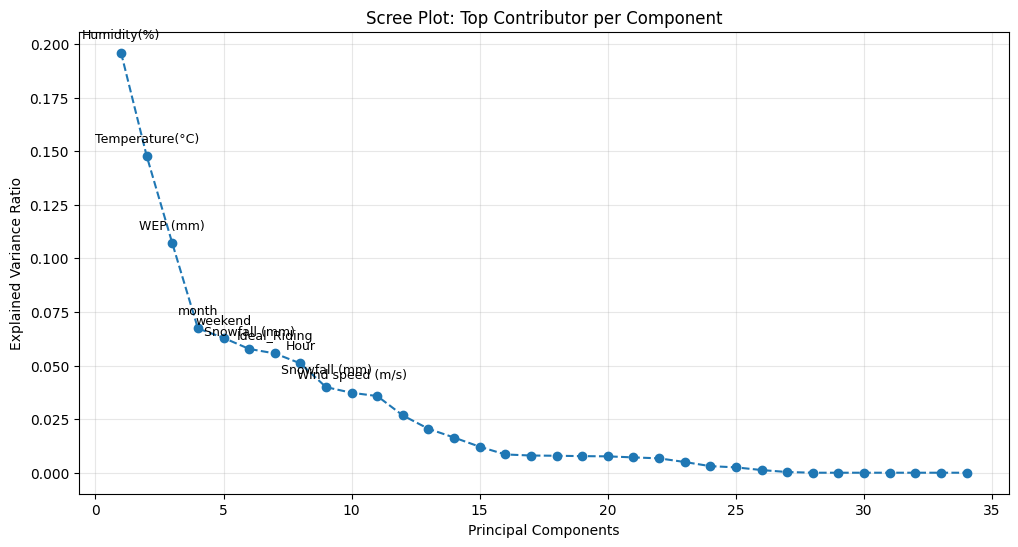

In [352]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# 1. PCA 실행
pca = PCA()
pca.fit(X_tr_EDA)

# 2. 각 주성분(PC)별로 가장 영향력이 큰(절대값 기준) 원본 변수 찾기
# pca.components_ 는 (주성분 개수, 원본 변수 개수) 형태입니다.
feature_names = X_tr_EDA.columns
top_features = [feature_names[np.argmax(np.abs(pc))] for pc in pca.components_]

# 3. 시각화
plt.figure(figsize=(12, 6))
x_range = range(1, len(pca.explained_variance_ratio_) + 1)
plt.plot(x_range, pca.explained_variance_ratio_, marker='o', linestyle='--')

# 4. 점 위에 가장 기여도가 높은 변수 이름 표시 (Annotation)
for i, txt in enumerate(top_features):
    # 정보량이 너무 적은 뒷부분은 생략.
    if i < 10 : # 상위 10개 성분만 이름 표시
        plt.annotate(txt, (x_range[i], pca.explained_variance_ratio_[i]),
                     textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

plt.title('Scree Plot: Top Contributor per Component')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.grid(True, alpha=0.3)
plt.show()

In [353]:
# PC 개수 설정
n_PC = 4

X_train_pca = X_tr_EDA.copy()
X_val_pca = X_va_EDA.copy()
X_test_pca = X_te_EDA.copy()

pca = PCA(n_components=n_PC)
train_pca = pca.fit_transform(X_tr_EDA)
val_pca = pca.transform(X_va_EDA)
test_pca = pca.transform(X_te_EDA)

pca_cols = [f'PC{i+1}' for i in range(n_PC)]
X_train_pca[pca_cols] = pd.DataFrame(train_pca, columns=pca_cols, index=X_tr_EDA.index)
X_val_pca[pca_cols] = pd.DataFrame(val_pca, columns=pca_cols, index=X_va_EDA.index)
X_test_pca[pca_cols] = pd.DataFrame(test_pca, columns=pca_cols, index=X_te_EDA.index)
X_train_pca.head()

,Seasons_Autumn,Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_Holiday,Holiday_No Holiday,Functioning Day_No,Functioning Day_Yes,dayname_Friday,dayname_Monday,...,WEP (mm),Discomfort_Index,Is_Steamy,Ideal_Riding,Is_Dry,Is_Raining,PC1,PC2,PC3,PC4
0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,-0.147456,0.424277,-0.478133,-0.373017,-0.274784,-0.261744,0.514886,0.154656,-1.541726,1.334780
1,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,-0.056116,-2.051273,-0.478133,-0.373017,-0.274784,-0.261744,-0.238482,-3.558336,0.907423,-0.281960
2,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,-0.147456,-1.517143,-0.478133,-0.373017,-0.274784,-0.261744,-0.482142,-2.780176,0.085943,0.284314
3,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,-0.147456,1.421099,-0.478133,-0.373017,-0.274784,-0.261744,-0.750724,2.188103,-0.719821,-0.050371
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,-0.147456,-0.294783,-0.478133,-0.373017,3.639217,-0.261744,-2.549098,-0.050116,1.745081,0.872068


## 비지도 학습 K-Means 클러스터링
> K-means Clustering  
데이터를 K개의 군집(Cluster)으로 나누는 비지도 학습 알고리즘이다.  
각 데이터는 가장 가까운 중심점(Centroid)을 기준으로 군집에 할당되며,  
군집 내 분산을 최소화하는 방향으로 중심점을 반복적으로 갱신한다.  
주로 데이터의 패턴 탐색, 그룹 분류, 세분화(Segmentation)에 사용된다.

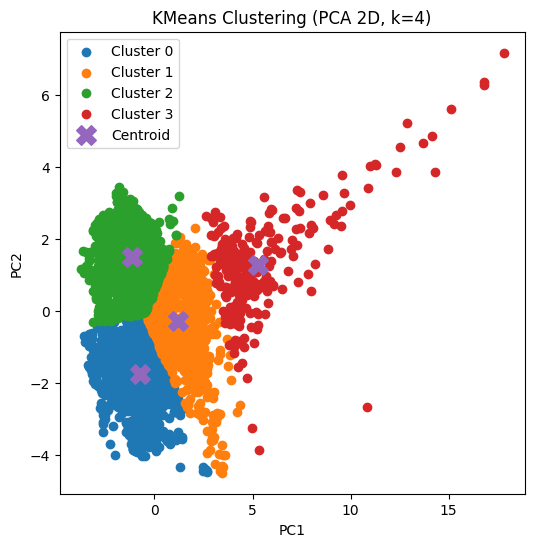

In [354]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# PCA를 통한 K-means Clustering 군집 시각화

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_tr_EDA)

kmeans4 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels4 = kmeans4.fit_predict(X_pca)

plt.figure(figsize=(6,6))
for cid in range(4):
    plt.scatter(
        X_pca[labels4 == cid, 0],
        X_pca[labels4 == cid, 1],
        label=f"Cluster {cid}"
    )

centers = kmeans4.cluster_centers_
plt.scatter(centers[:,0], centers[:,1], marker="X", s=200, label="Centroid")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clustering (PCA 2D, k=4)")
plt.legend()
plt.show()

In [355]:
# 비지도 학습

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_tr_EDA)

X_train_cl = X_tr_EDA.copy()
X_train_cl['cluster'] = clusters
X_train_cl.head()

,Seasons_Autumn,Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_Holiday,Holiday_No Holiday,Functioning Day_No,Functioning Day_Yes,dayname_Friday,dayname_Monday,...,Snowfall (mm),month,weekend,WEP (mm),Discomfort_Index,Is_Steamy,Ideal_Riding,Is_Dry,Is_Raining,cluster
0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,-0.178106,0.711006,-0.632835,-0.147456,0.424277,-0.478133,-0.373017,-0.274784,-0.261744,1
1,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,2.385915,-1.626841,-0.632835,-0.056116,-2.051273,-0.478133,-0.373017,-0.274784,-0.261744,1
2,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,-0.178106,-1.626841,1.580192,-0.147456,-1.517143,-0.478133,-0.373017,-0.274784,-0.261744,1
3,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,-0.178106,0.418775,1.580192,-0.147456,1.421099,-0.478133,-0.373017,-0.274784,-0.261744,0
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,-0.178106,1.295468,-0.632835,-0.147456,-0.294783,-0.478133,-0.373017,3.639217,-0.261744,1


In [356]:
X_train.head()

,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (mm),Seasons,Holiday,...,month,dayname,weekend,WEP (mm),Discomfort_Index,Is_Steamy,Ideal_Riding,Is_Dry,Is_Raining,Sunlight_Level
4369,7,17.8,76,0.5,1729,0.08,0.0,0.0,Autumn,No Holiday,...,9,Tuesday,0,0.0,63.24272,0,0,0,0,0
5995,3,-8.6,68,3.3,2000,0.00,0.0,0.1,Winter,No Holiday,...,1,Tuesday,0,0.1,23.82048,0,0,0,0,0
3181,3,-6.5,42,0.7,1996,0.00,0.0,0.0,Winter,No Holiday,...,1,Saturday,1,0.0,32.32630,0,0,0,0,0
2676,9,29.7,58,1.3,1955,1.68,0.0,0.0,Summer,No Holiday,...,8,Saturday,1,0.0,79.11674,0,0,0,0,1
2417,12,7.9,14,1.7,1688,1.81,0.0,0.0,Autumn,No Holiday,...,11,Wednesday,0,0.0,51.79194,0,0,1,0,1


In [357]:
X_train_cl['y_train'] = y_train

X_train_cl.groupby('cluster')['y_train'].agg(mean='mean', median='median', std='std').round(2)


,mean,median,std
cluster,,,
0,692.47,510.5,634.56
1,722.61,531.0,660.71
2,736.63,533.0,677.42
3,761.60,362.0,815.10


In [358]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

def diagnostic_clean_view(models_dict, X_val, y_val, is_log=False):
    """
    1. 스케일링 복원 (0.xxxx -> 원본 단위)
    2. 이진 분류 컬럼(One-hot) 제거하여 가독성 극대화
    """
    # 스케일러가 학습한 수치형 컬럼 리스트 추출
    try:
        numeric_cols = scaler.feature_names_in_.tolist()
    except:
        # 스케일러에 정보가 없을 경우를 대비한 백업 로직
        numeric_cols = [c for c in X_val.columns if '_' not in c]

    for name, model in models_dict.items():
        # 1. 예측 및 복원
        preds_raw = model.predict(X_val)
        preds = np.expm1(preds_raw) if is_log else preds_raw
        preds = np.maximum(0, preds)

        # 2. 분석용 데이터프레임 생성
        analysis_df = X_val.copy()

        # 3. 스케일링 복원 (원본 단위로)
        analysis_df[numeric_cols] = scaler.inverse_transform(analysis_df[numeric_cols])

        # 4. 결과 및 오차 계산
        analysis_df['Actual'] = y_val.values
        analysis_df['Predicted'] = preds
        analysis_df['Error'] = np.abs(analysis_df['Actual'] - analysis_df['Predicted'])

        # 5. [핵심] 이진 분류 컬럼 및 불필요한 컬럼 제거
        # 컬럼명에 '_'가 포함된 것(One-hot)이나 0/1로만 구성된 컬럼 필터링
        display_cols = ['Actual', 'Predicted', 'Error'] + numeric_cols
        # 중복 제거 및 존재하는 컬럼만 선택
        display_cols = list(dict.fromkeys([c for c in display_cols if c in analysis_df.columns]))

        final_view = analysis_df[display_cols]

        print(f"\n🔍 [{name}] 핵심 오차 분석 (이진 컬럼 제외 / 원본 단위 복원):")
        worst_20 = final_view.sort_values(by='Error', ascending=False).head(20)

        # 소수점 둘째자리까지 반올림하여 출력
        display(worst_20.round(2))

# --- 실행부 ---
# 1. 모델 객체 확인 (교안 원본 변수명 유지)
target_models = {
    'DecisionTree': dt,
    'RandomForest': rf,
    'XGBoost': xgb
}

# 2. 진단 함수 호출
# 로그 변환을 사용하지 않는 교안 흐름이라면 is_log=False 유지
diagnostic_clean_view(target_models, X_va_EDA, y_val, is_log=False)


🔍 [DecisionTree] 핵심 오차 분석 (이진 컬럼 제외 / 원본 단위 복원):


,Actual,Predicted,Error,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (mm),month,weekend,WEP (mm),Discomfort_Index,Is_Steamy,Ideal_Riding,Is_Dry,Is_Raining
1683,103,2479.0,2376.0,16.0,19.1,52.0,0.9,1583.0,0.37,0.0,0.0,4.0,1.0,0.0,64.17,0.0,1.0,0.0,0.0
986,2082,174.0,1908.0,8.0,11.8,80.0,3.7,1518.0,0.16,0.0,0.0,10.0,0.0,0.0,53.76,1.0,0.0,0.0,0.0
605,2261,520.0,1741.0,18.0,17.5,79.0,1.5,2000.0,0.57,0.0,0.0,5.0,0.0,0.0,62.86,0.0,0.0,0.0,0.0
826,44,1707.0,1663.0,19.0,24.1,93.0,2.1,1118.0,0.23,1.5,0.0,7.0,0.0,1.5,74.71,1.0,0.0,0.0,1.0
1279,148,1622.0,1474.0,8.0,10.6,89.0,1.5,689.0,0.02,0.0,0.0,11.0,0.0,0.0,51.50,1.0,0.0,0.0,0.0
41,3556,2163.0,1393.0,18.0,24.1,57.0,2.9,1301.0,0.56,0.0,0.0,6.0,0.0,0.0,71.27,0.0,1.0,0.0,0.0
471,2153,843.0,1310.0,18.0,24.8,83.0,0.8,1947.0,0.26,0.0,0.0,8.0,0.0,0.0,74.90,1.0,0.0,0.0,0.0
1027,1686,400.0,1286.0,8.0,23.1,80.0,0.2,1066.0,0.27,0.1,0.0,8.0,0.0,0.1,71.87,1.0,0.0,0.0,1.0
1237,1058,2338.0,1280.0,19.0,25.7,47.0,1.8,2000.0,0.04,0.0,0.0,6.0,1.0,0.0,72.35,0.0,0.0,0.0,0.0
1377,754,1987.0,1233.0,13.0,23.6,66.0,2.1,1689.0,0.87,0.0,0.0,9.0,1.0,0.0,71.40,0.0,0.0,0.0,0.0



🔍 [RandomForest] 핵심 오차 분석 (이진 컬럼 제외 / 원본 단위 복원):


,Actual,Predicted,Error,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (mm),month,weekend,WEP (mm),Discomfort_Index,Is_Steamy,Ideal_Riding,Is_Dry,Is_Raining
1683,103,1517.22,1414.22,16.0,19.1,52.0,0.9,1583.0,0.37,0.0,0.0,4.0,1.0,0.0,64.17,0.0,1.0,0.0,0.0
1237,1058,2262.49,1204.49,19.0,25.7,47.0,1.8,2000.0,0.04,0.0,0.0,6.0,1.0,0.0,72.35,0.0,0.0,0.0,0.0
1417,600,1664.90,1064.90,8.0,14.8,80.0,0.3,1921.0,0.31,0.0,0.0,5.0,0.0,0.0,58.57,1.0,0.0,0.0,0.0
632,234,1199.09,965.09,15.0,19.6,44.0,2.4,1885.0,0.47,0.2,0.0,4.0,1.0,0.2,64.42,0.0,1.0,0.0,1.0
1250,384,1299.37,915.37,14.0,20.7,32.0,1.5,1996.0,0.69,0.0,0.0,4.0,1.0,0.0,65.05,0.0,1.0,0.0,0.0
486,2474,1610.26,863.74,16.0,25.8,50.0,1.7,1152.0,0.66,0.0,0.0,6.0,0.0,0.0,72.82,0.0,0.0,0.0,0.0
578,2379,1535.94,843.06,16.0,19.5,65.0,2.9,857.0,1.97,0.0,0.0,5.0,1.0,0.0,65.35,0.0,0.0,0.0,0.0
876,163,1001.02,838.02,15.0,21.1,72.0,2.7,663.0,0.31,0.1,0.0,5.0,0.0,0.1,68.14,0.0,0.0,0.0,1.0
1640,657,1485.95,828.95,7.0,19.4,69.0,0.3,1277.0,0.42,0.0,0.0,6.0,0.0,0.0,65.40,0.0,0.0,0.0,0.0
664,373,1188.94,815.94,23.0,24.9,87.0,0.5,658.0,0.00,0.0,0.0,7.0,0.0,0.0,75.47,1.0,0.0,0.0,0.0



🔍 [XGBoost] 핵심 오차 분석 (이진 컬럼 제외 / 원본 단위 복원):


,Actual,Predicted,Error,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (mm),month,weekend,WEP (mm),Discomfort_Index,Is_Steamy,Ideal_Riding,Is_Dry,Is_Raining
1237,1058,2250.489990,1192.49,19.0,25.7,47.0,1.8,2000.0,0.04,0.0,0.0,6.0,1.0,0.0,72.35,0.0,0.0,0.0,0.0
1417,600,1535.930054,935.93,8.0,14.8,80.0,0.3,1921.0,0.31,0.0,0.0,5.0,0.0,0.0,58.57,1.0,0.0,0.0,0.0
1683,103,1004.320007,901.32,16.0,19.1,52.0,0.9,1583.0,0.37,0.0,0.0,4.0,1.0,0.0,64.17,0.0,1.0,0.0,0.0
1541,3016,2157.209961,858.79,18.0,27.5,77.0,2.1,1897.0,0.46,0.0,0.0,7.0,0.0,0.0,78.53,0.0,0.0,0.0,0.0
1476,1798,968.039978,829.96,22.0,23.6,82.0,1.8,1673.0,0.00,0.0,0.0,9.0,0.0,0.0,72.85,1.0,0.0,0.0,0.0
1640,657,1486.489990,829.49,7.0,19.4,69.0,0.3,1277.0,0.42,0.0,0.0,6.0,0.0,0.0,65.40,0.0,0.0,0.0,0.0
1250,384,1178.239990,794.24,14.0,20.7,32.0,1.5,1996.0,0.69,0.0,0.0,4.0,1.0,0.0,65.05,0.0,1.0,0.0,0.0
785,389,1123.469971,734.47,7.0,14.2,81.0,0.3,1991.0,0.13,0.0,0.0,5.0,0.0,0.0,57.61,1.0,0.0,0.0,0.0
578,2379,1645.199951,733.80,16.0,19.5,65.0,2.9,857.0,1.97,0.0,0.0,5.0,1.0,0.0,65.35,0.0,0.0,0.0,0.0
928,670,1397.540039,727.54,8.0,20.7,73.0,0.8,2000.0,0.30,0.2,0.0,7.0,0.0,0.2,67.59,0.0,0.0,0.0,1.0


In [359]:
# [원본 검색] 대여수가 2598대인 모든 행 찾기
target_count = 600
display(df_train[df_train['Rented Bike Count'] == target_count])

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,id
931,07/05/2018,600,8,14.8,80,0.3,1921,11.3,0.31,0.0,0.0,Spring,No Holiday,Yes,14261
945,13/07/2018,600,2,24.9,86,1.3,1469,22.3,0.00,0.0,0.0,Summer,No Holiday,Yes,15781
1365,26/08/2018,600,2,22.1,84,0.6,2000,19.2,0.00,0.0,0.0,Summer,No Holiday,Yes,13201
1773,05/08/2018,600,13,33.0,56,3.5,1857,23.0,2.68,0.0,0.0,Summer,No Holiday,Yes,17649
2493,27/11/2018,600,14,11.6,70,1.5,388,6.3,0.45,0.0,0.0,Autumn,No Holiday,Yes,17265
2814,21/04/2018,600,8,14.6,54,0.9,431,5.3,0.89,0.0,0.0,Spring,No Holiday,Yes,13139
4744,22/03/2018,600,7,0.6,85,1.5,1321,-1.6,0.01,0.0,0.0,Spring,No Holiday,Yes,12434
5509,03/08/2018,600,15,37.4,44,3.2,1499,23.0,2.71,0.0,0.0,Summer,No Holiday,Yes,12872
5598,17/10/2018,600,1,11.5,74,1.2,1305,7.0,0.00,0.0,0.0,Autumn,No Holiday,Yes,18458


In [360]:
# 날짜 검색 후 대여량(Rented Bike Count) 많은 순서로 정렬
target_date = '12/05/2018'
result = df_train[df_train['Date'] == target_date].sort_values(by='Rented Bike Count', ascending=False)

display(result)

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,id
4039,12/05/2018,862,0,16.1,54,1.3,1052,6.7,0.00,0.0,0.0,Spring,No Holiday,Yes,14233
4784,12/05/2018,669,1,15.9,51,1.8,866,5.7,0.00,0.0,0.0,Spring,No Holiday,Yes,14404
3783,12/05/2018,207,4,15.0,61,0.8,867,7.5,0.00,0.0,0.0,Spring,No Holiday,Yes,12008
2423,12/05/2018,70,5,15.0,61,1.2,903,7.5,0.00,0.0,0.0,Spring,No Holiday,Yes,12852
1417,12/05/2018,50,23,15.8,98,1.6,235,15.4,0.00,1.0,0.0,Spring,No Holiday,Yes,11170
963,12/05/2018,37,6,14.4,71,1.3,560,9.2,0.00,0.4,0.0,Spring,No Holiday,Yes,18060
2419,12/05/2018,34,16,13.8,97,0.7,196,13.3,0.12,1.5,0.0,Spring,No Holiday,Yes,12195
1531,12/05/2018,29,19,15.5,97,0.7,403,15.0,0.00,2.0,0.0,Spring,No Holiday,Yes,13325
1928,12/05/2018,29,20,15.7,97,0.3,343,15.2,0.00,1.0,0.0,Spring,No Holiday,Yes,14299
3390,12/05/2018,25,21,15.8,97,0.6,193,15.3,0.00,0.5,0.0,Spring,No Holiday,Yes,11782


In [361]:
target_count = 'Holiday'
display(df_train[df_train['Holiday'] == target_count])

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,id
24,24/12/2017,266,0,5.6,78,0.6,196,2.0,0.00,0.0,0.0,Winter,Holiday,Yes,18106
32,15/02/2018,240,13,2.2,18,3.4,1942,-19.7,2.30,0.0,0.0,Winter,Holiday,Yes,18372
42,16/02/2018,210,17,2.5,48,4.2,1979,-7.4,0.76,0.0,0.0,Winter,Holiday,Yes,10183
64,25/12/2017,115,2,-1.8,53,4.1,1825,-10.1,0.00,0.0,0.0,Winter,Holiday,Yes,11883
72,25/12/2017,176,22,-1.3,53,1.7,2000,-9.6,0.00,0.0,0.0,Winter,Holiday,Yes,17800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6916,25/12/2017,72,4,-3.0,51,3.2,2000,-11.7,0.00,0.0,0.0,Winter,Holiday,Yes,10593
6934,24/09/2018,426,10,18.5,38,3.3,2000,3.8,2.02,0.0,0.0,Autumn,Holiday,Yes,14251
6950,17/02/2018,71,1,-3.1,36,3.5,2000,-16.0,0.00,0.0,0.0,Winter,Holiday,Yes,13053
6970,09/10/2018,0,21,16.8,52,1.6,2000,6.8,0.00,0.0,0.0,Autumn,Holiday,No,14166


In [362]:
# 비율로 확인 (0.96, 0.03 등)
X_tr_EDA['Functioning Day_Yes'].value_counts(normalize=True)

,proportion
Functioning Day_Yes,
1.0,0.966705
0.0,0.033295


In [363]:
# 비율로 확인 (0.96, 0.03 등)
X_tr_EDA['Holiday_No Holiday'].value_counts(normalize=True)

,proportion
Holiday_No Holiday,
1.0,0.950342
0.0,0.049658
